# **Slice profiles through 3D DTMs**

<hr>

# Preliminaries

In [1]:
import os
from typing import Any
from functools import partial
from pprint import PrettyPrinter

import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
# pv.global_theme.multi_samples = 1
# os.environ["VTK_DEFAULT_OPENGL_WINDOW"] = "vtkOSOpenGLRenderWindow"
# os.environ['LIBGL_ALWAYS_SOFTWARE'] = '1'

import shapely
import shapely.ops
import shapely.plotting

# import sys
# sys.path.append("../Packages")
from erosionfront.topo.analysis import ( 
    patch_up,
    Geometry,
    ProfileData,
    Profiles,
)
from erosionfront.visualization.viz2d import Viz2D
from erosionfront.misc.save import create_directories, export_plots

pp = PrettyPrinter(indent=4).pprint

<hr>

# Data


## Read

In [2]:
data_path = os.path.join(
    os.environ.get("HOME"),
    "Data", "RockSlopes", "Google3D", "MonumentValley",
)
data_set = "KingThrone_MV"
data_file = os.path.join(data_path, data_set, data_set+".glb",)
raw_mesh = pv.read(data_file)
data_file

'/Users/cps/Data/RockSlopes/Google3D/MonumentValley/KingThrone_MV/KingThrone_MV.glb'

Rebuild the raw mesh (exported from Blender, with actual mesh doubly nested and with $y$ axis vertical) into a mesh with $z$ vertical. 

This PyVista-format mesh is a multiblock polydata object, meaning that the mesh is in multiple pieces. As a result, the mesh rotation and assembly has to be done by rotating and appending one block at a time to a fresh multiblock object.

In [3]:
mesh = patch_up(raw_mesh)



## Profiles

Find approximate $x$ and $y$ extents of DTM.

In [4]:
geometry = Geometry(mesh,)

Choose a set of profiles, specifing the origin and orientation of each in turn. This action is achieved here by building a dictionary of function calls, each tailored to the chosen profiling task.

In [5]:
info = {
    1: dict(name="demo1", orientation=0,   offset=(0,-2,0),),
    2: dict(name="demo2", orientation=-5,  offset=(0,-13,0),),
    3: dict(name="demo3", orientation=-10, offset=(0,-33,0),),
    4: dict(name="demo4", orientation=-15, offset=(0,-50,0),)
}
pp(info)

{   1: {'name': 'demo1', 'offset': (0, -2, 0), 'orientation': 0},
    2: {'name': 'demo2', 'offset': (0, -13, 0), 'orientation': -5},
    3: {'name': 'demo3', 'offset': (0, -33, 0), 'orientation': -10},
    4: {'name': 'demo4', 'offset': (0, -50, 0), 'orientation': -15}}


In [6]:
profiles = Profiles(mesh, geometry, info)

Carry out the set of profile slicings:

In [7]:
profiles.perform_slicing()

Extract a slice profile piece by piece, taking each of the polydata blocks in the mesh in turn, putting them in `slice_segments` after cleaning the empty ones.

Then extract the paired points along each slice segment and concatenate into an array of paired points defining `slice_chords`.



In [8]:
profiles.perform_chord_extraction()

In [9]:
profiles.data[1].normals

Compute chord parallel vectors, normals, mid-points, and angles relative to vertical – splitting these angles into forward and backward angle variables (`None` denotes not).

In [10]:
profiles.perform_angles_computation()

<hr>

# Visualization

In [11]:
viz = Viz2D()



## 3D

Plot in 3D.

In [12]:
camera_positions = dict(
    cp1 = [(266.39049147002277, -459.18486641077783, 2159.019405241339),
            (32.92616900593576, 24.58595774628902, 1834.898535185903),
            (-0.21927231785268633, 0.4678194617019339, 0.8561919188338696)],
    cp2 = [(44.25772261469757, -35.8741016053509, 2165.4333868455697),
            (28.476930218040405, 19.484337390053682, 1828.3407609014537),
            (-0.9617430620783376, -0.27395306420937104, 3.3977631260576536e-05)],
    cp3 = [(97.58174577406129, -130.59291347134882, 2139.998909159092),
            (78.21167362338113, -15.860921799114806, 1786.0313168586015),
            (-0.26449414154520484, 0.9130602351238705, 0.310425282674926)],
    cp4 = [(446.580227217223, 26.358682199398505, 1845.0473951798613),
            (79.36272753772259, -11.84978260253392, 1794.8168551288063),
            (-0.13346258211599613, -0.01992522828860888, 0.9908535332997397)],
    cp5 = [(312.24228656608136, 8.44633632579672, 2318.063780194286),
            (71.19601046649771, 2.5906735531346623, 1840.226619671927),
            (-0.8911891798989233, -0.055359414942425106, 0.45024124734226284)]
)

In [13]:
pl = viz.plot_3d(mesh, geometry, profiles,)

2026-06-02 19:14:10.901 (  59.138s) [          745D2A]     vtkOpenGLState.cxx:1806  WARN| Hardware does not support the number of textures defined.
2026-06-02 19:14:10.901 (  59.138s) [          745D2A]     vtkOpenGLState.cxx:1806  WARN| Hardware does not support the number of textures defined.
2026-06-02 19:14:10.901 (  59.138s) [          745D2A]     vtkOpenGLState.cxx:1806  WARN| Hardware does not support the number of textures defined.
2026-06-02 19:14:10.916 (  59.153s) [          745D2A]     vtkOpenGLState.cxx:1806  WARN| Hardware does not support the number of textures defined.
2026-06-02 19:14:10.916 (  59.153s) [          745D2A]     vtkOpenGLState.cxx:1806  WARN| Hardware does not support the number of textures defined.
2026-06-02 19:14:10.916 (  59.153s) [          745D2A]     vtkOpenGLState.cxx:1806  WARN| Hardware does not support the number of textures defined.
2026-06-02 19:14:10.916 (  59.153s) [          745D2A]     vtkOpenGLState.cxx:1806  WARN| Hardware does not supp

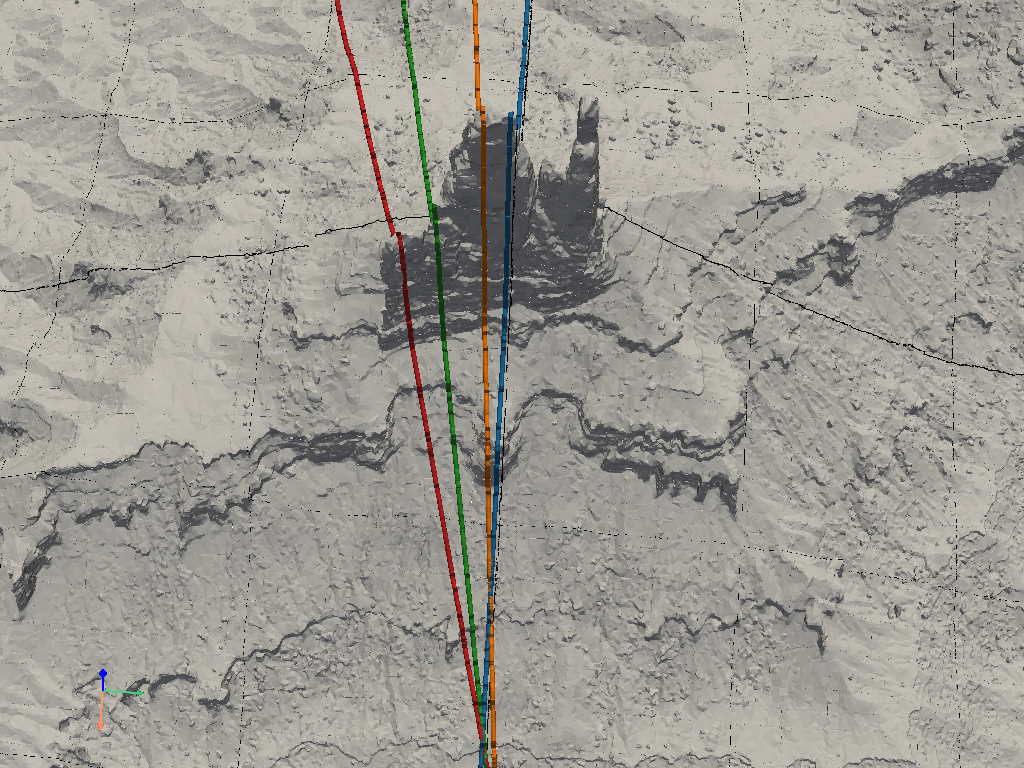

In [14]:
pl.show(cpos=camera_positions.get("cp5"), jupyter_backend="trame", )  
# interactive=True, interactive_update=True, 

In [15]:
pl.camera_position

CameraPosition(position=(312.24228656608136, 8.44633632579672, 2318.063780194286),
               focal_point=(71.19601046649771, 2.5906735531346623, 1840.226619671927),
               viewup=(-0.8911891798989234, -0.05535941494242511, 0.4502412473422629))



## 2D

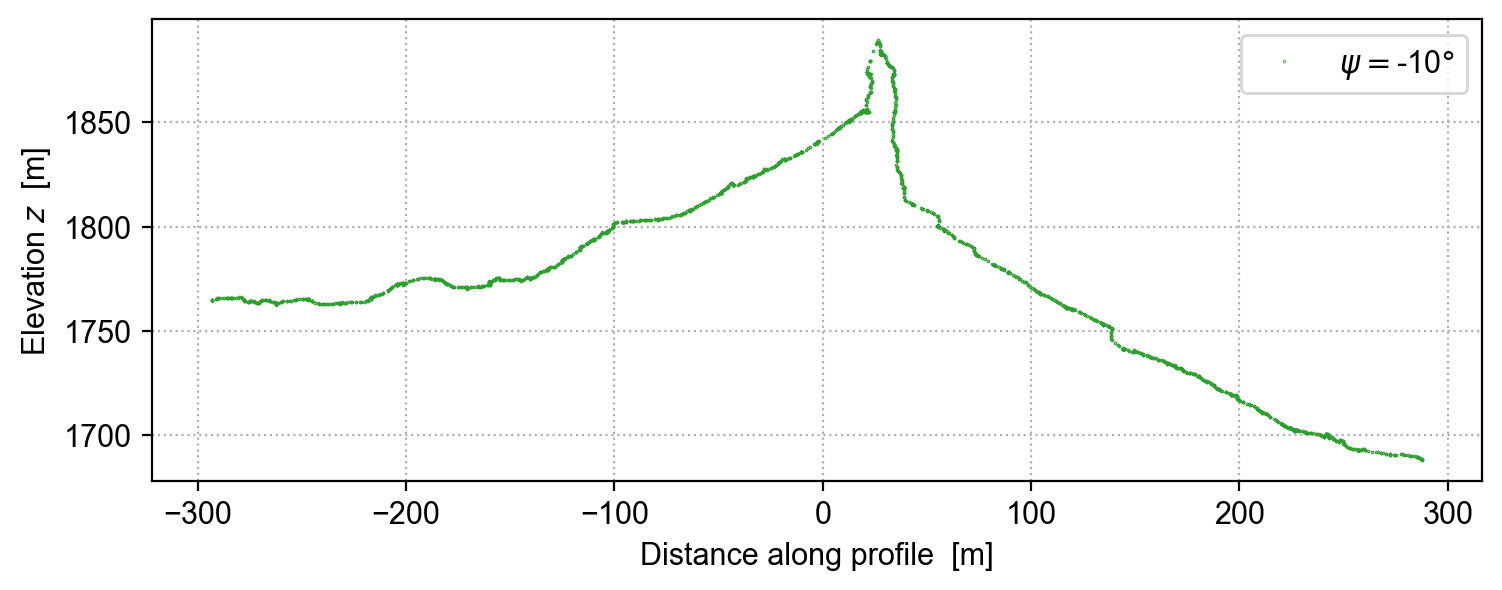

In [16]:
viz.plot_profiles(
    "Elevation", 
    profiles, 
    choices=("demo3",), 
    scale=2, 
    fig_size=(6,1.5,), 
    marker_size=0.5, 
    line_width=None, 
) #0.05*20

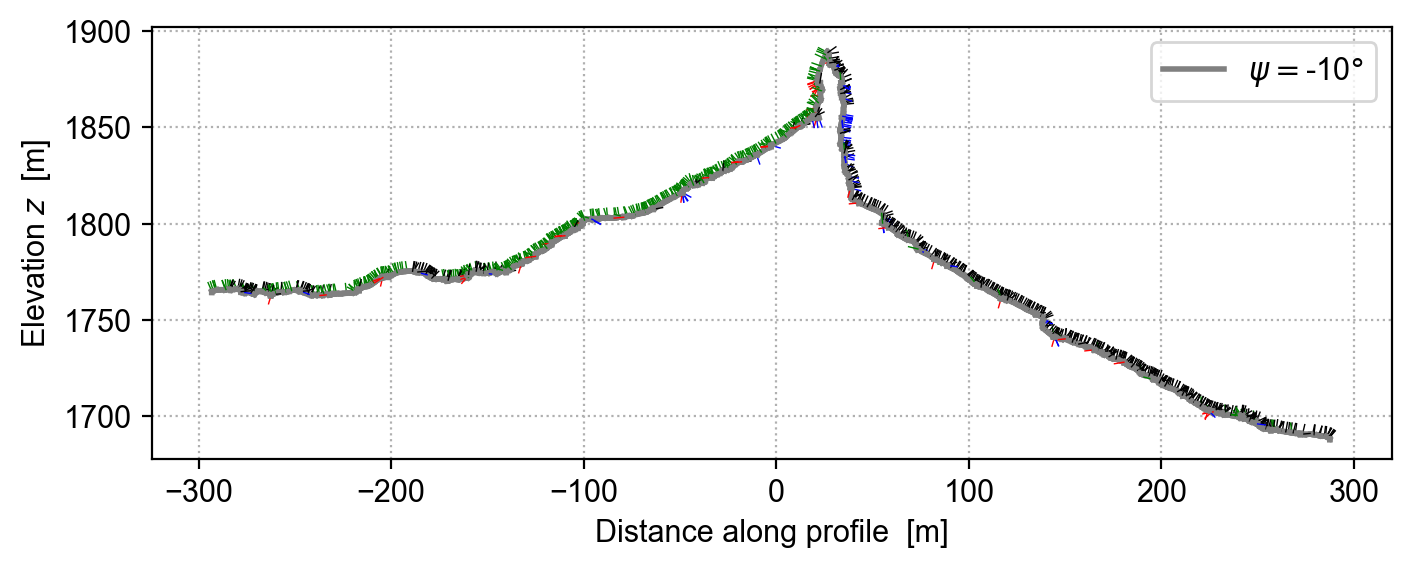

In [17]:
xlim_ = (17,40,) #(28,30,) #(-278,-277)
ylim_ = (1860,1880,) #(1850,1870,)
viz.plot_profiles(
    "ZoomElevation", 
    profiles, 
    choices=("demo3",), 
    scale=2, fig_size=(4,4,), 
    marker_size=None, 
    line_width=2, 
    # xlim=xlim_, ylim=ylim_, 
    do_equal=True,
    # use_normals=True,
    do_normals=True,
    vector_sf=5,
    # do_flip_orientation=True,
    θ_clip=(5,85,),
) #0.05*20

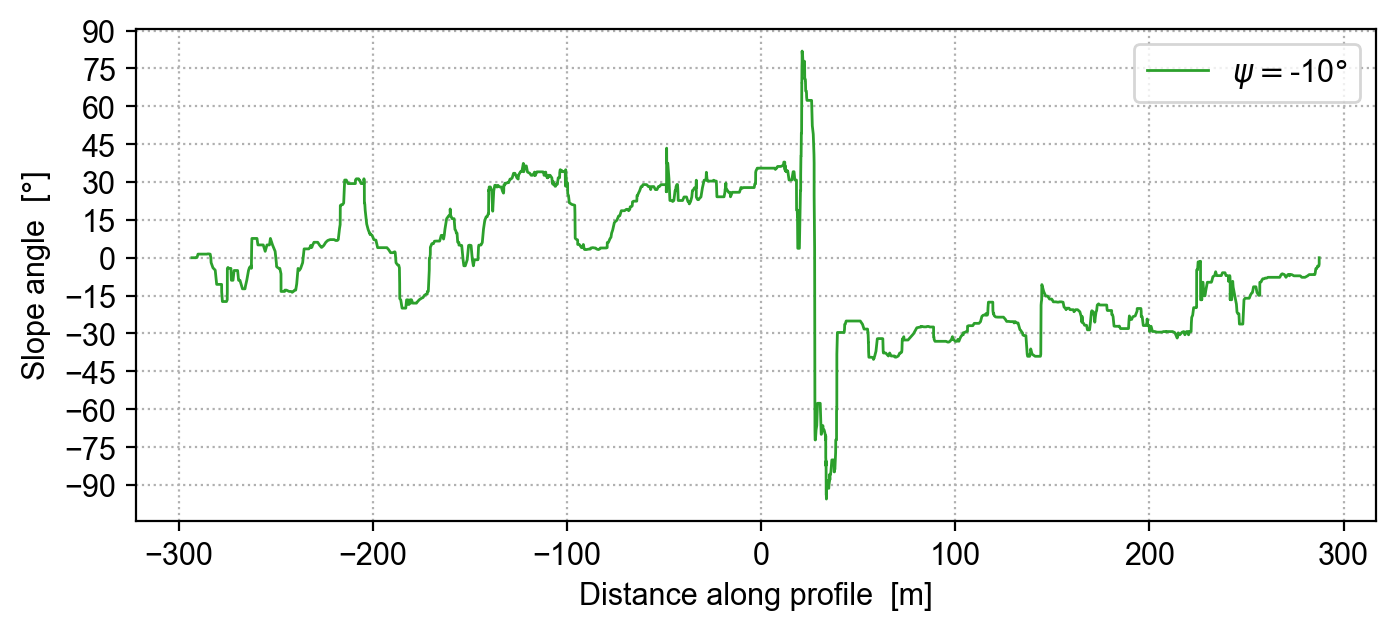

In [18]:
viz.plot_slopes(
    "Slope", 
    profiles, 
    choices=("demo3",), 
    w_filter=31, 
    scale=2, 
    fig_size=(4,1.6),
)

<hr>

# Cleaning

https://shapely.readthedocs.io/en/2.0.3/manual.html#MultiLineString

In [19]:
profile_ = profiles.data[3]
chords_ = profile_.chords
c = [
    (np.array([
        (chord_[0][0],chord_[1][0]), (chord_[0][1],chord_[1][1])
    ]))
    for chord_ in chords_
]
# c += [ (c[-1][1], c[0][0],) ]

In [20]:
c_mls = shapely.MultiLineString(c)
c_mlp = shapely.ops.polygonize_full(c_mls)
c_gc = c_mlp[2]
c_gc2 = c_gc.simplify(tolerance=100, preserve_topology=False,)
c_merged = shapely.ops.linemerge(c_gc)
len(c_merged.geoms)

84

In [21]:
c_lines = [line_ for line_ in c_merged.geoms]
c_lines[:4], len(c_lines)
[len(line_.coords) for line_ in c_lines][:10]

[32, 44, 32, 30, 25, 3, 28, 3, 4, 10]

In [22]:
c_hull = shapely.concave_hull(c_gc)
type(c_gc2)

shapely.geometry.collection.GeometryCollection

(1860.0, 1880.0)

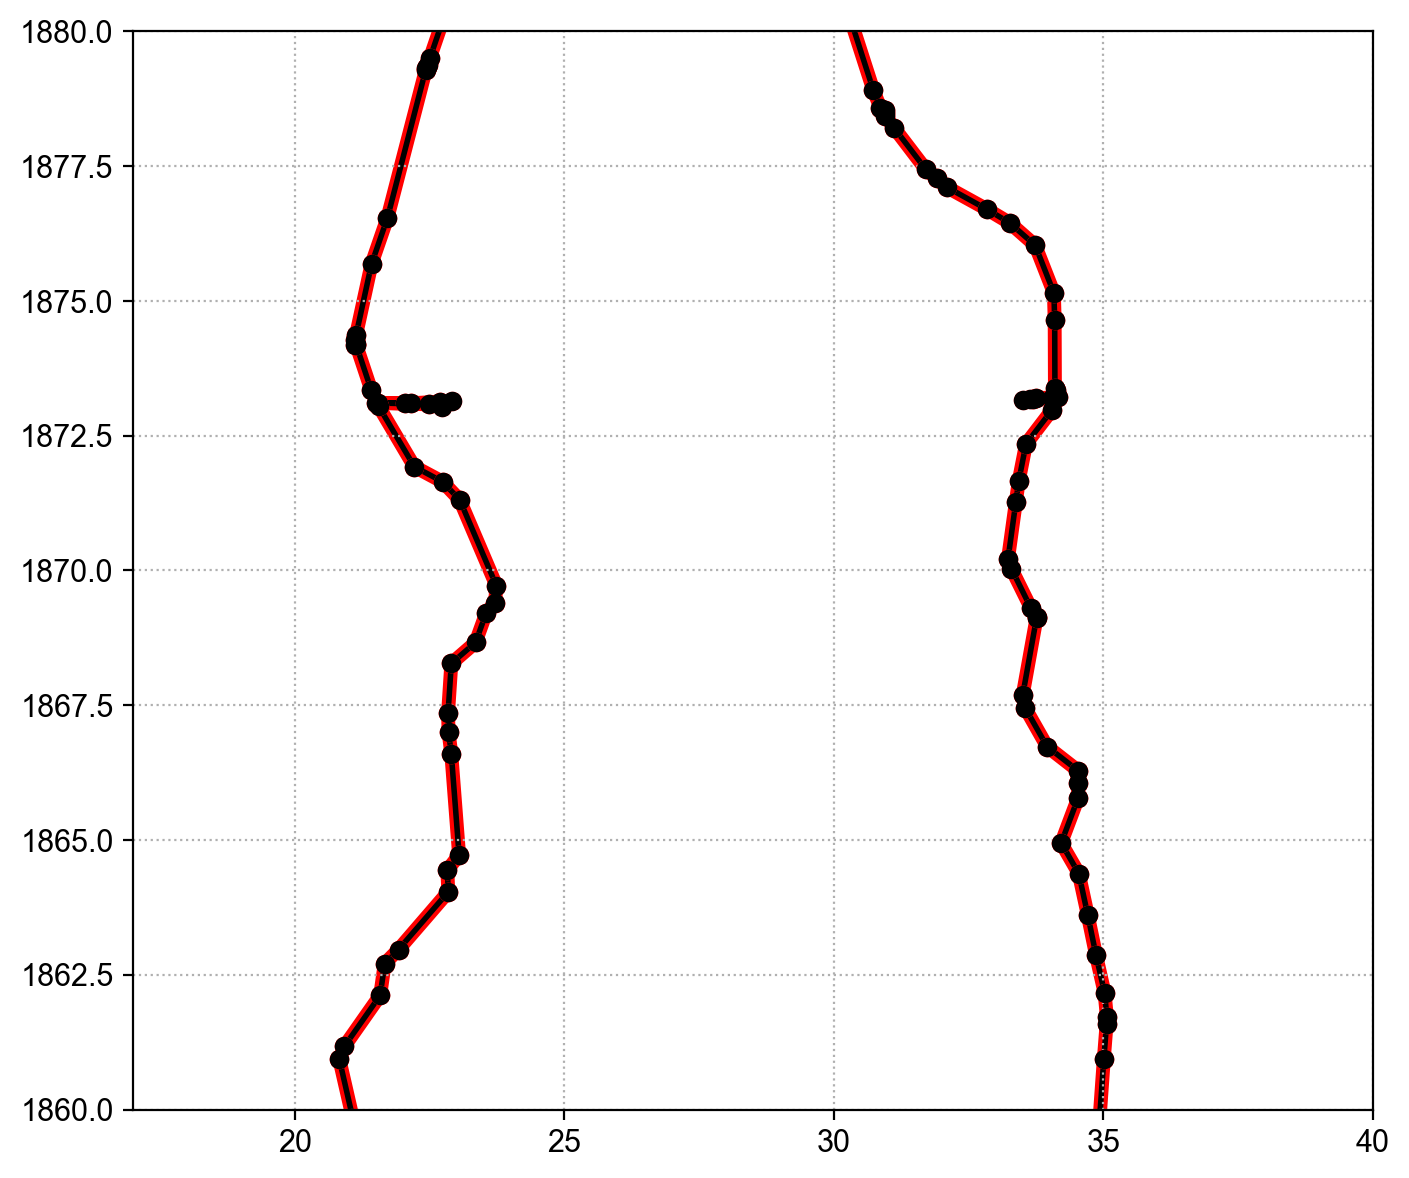

In [23]:
plt.figure(figsize=(8,8,),)
shapely.plotting.plot_line(c_mls, color="r", linewidth=5, )
shapely.plotting.plot_line(c_merged, color="k", linewidth=2, )
# shapely.plotting.plot_points(c_gc, color="r", marker=".", markersize=15,)
# shapely.plotting.plot_points(c_gc2, color="g", marker=".", markersize=10,)
# shapely.plotting.plot_polygon(c_hull, linewidth=1,)
# shapely.plotting.plot_points(c_hull, marker=".", markersize=5, color="k",)
plt.grid(ls=":",)
xlim_ = (17,40,) #(28,30,) #(-278,-277)
ylim_ = (1860,1880,) #(1850,1870,)
plt.xlim(xlim_)
plt.ylim(ylim_)

In [24]:
p = profiles.data[1].chords[:]
chord_dict = {
    i_: chord_ for i_, chord_ in enumerate(p)
}
# while len(chord_dict)>0:
chord_ = chord_dict.pop(list(chord_dict.keys())[0])
p1a_ = chord_[:,0]
p1b_ = chord_[:,1]
pts = [p1a_, p1b_]
i_ = 0
while len(chord_dict)>0 and i_<len(p):
    # print(len(chord_dict))
    for key_, chord_ in chord_dict.items():
        i_ += 1
        p2a_ = chord_[:,0]
        p2b_ = chord_[:,1]
        dp_ = np.linalg.norm(p2a_-p1b_)
        if dp_<1e-9:
            # print(i_, dp_)
            _ = chord_dict.pop(key_)
            pts += [p2b_,]
            p1a_ = p2a_
            p1b_ = p2b_
            break
print(len(pts))
p1a_, p1b_, pts

19


(array([-277.78991699, 1764.85070801]),
 array([-277.790802  , 1764.81530762]),
 [array([-286.80712891, 1762.7052002 ]),
  array([-286.65402222, 1762.77856445]),
  array([-285.50549316, 1763.02233887]),
  array([-285.43414307, 1763.01904297]),
  array([-285.35876465, 1763.05871582]),
  array([-283.00421143, 1763.91882324]),
  array([-282.58172607, 1764.0144043 ]),
  array([-281.79098511, 1764.44848633]),
  array([-281.78921509, 1764.44921875]),
  array([-280.4491272, 1764.5045166]),
  array([-280.2635498 , 1764.55725098]),
  array([-280.24383545, 1764.57226562]),
  array([-278.95510864, 1764.95898438]),
  array([-278.44241333, 1765.16564941]),
  array([-278.0380249 , 1765.31921387]),
  array([-277.89950562, 1765.36035156]),
  array([-277.82275391, 1765.40734863]),
  array([-277.78991699, 1764.85070801]),
  array([-277.790802  , 1764.81530762])])

<hr>

# Export

In [ ]:
plots_dir: str = create_directories((os.path.curdir,"",), "plots",)
export_plots(
    viz.fdict,
    plots_dir, #type: ignore
    "PDF",
    suffix="",
    dpi=150,
)